# Section 3 — INSTRUCTOR COPY
## Part 1: Solutions | Part 2: Visualization
---

## ▶ Load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df['species'] = iris_raw.target_names[iris_raw.target]

print('Data loaded successfully!')
print('Shape:', df.shape)

Data loaded successfully!
Shape: (150, 5)


---
# PART 1 — Solutions

## Q1 — First Look

In [2]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Q2 — Data Info

In [3]:
df.info()
print()
print('Missing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


## Q3 — Species Count

In [4]:
print('Number of species:', df['species'].unique())
print()
print('Flowers per species:')
print(df['species'].value_counts())

Number of species: ['setosa' 'versicolor' 'virginica']

Flowers per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Q4 — Summary Statistics

In [5]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Q5 — Groupby

In [6]:
df.groupby('species')['petal_length'].mean().round(2)

species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length, dtype: float64

## Q6 — Filter

In [7]:
big_petals = df[df['petal_length'] > 5]
print('Number of flowers with petal_length > 5:', len(big_petals))
big_petals.head()

Number of flowers with petal_length > 5: 42


,sepal_length,sepal_width,petal_length,petal_width,species
83,6.0,2.7,5.1,1.6,versicolor
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica
103,6.3,2.9,5.6,1.8,virginica


## Q7 — Filter + Groupby

In [8]:
big_petals = df[df['petal_length'] > 5]
big_petals.groupby('species')['sepal_width'].mean().round(2)

species
versicolor    2.70
virginica     3.04
Name: sepal_width, dtype: float64

## Q8 — BONUS

In [9]:
df.groupby('species')['petal_width'].mean().sort_values(ascending=False).round(2)

species
virginica     2.03
versicolor    1.33
setosa        0.25
Name: petal_width, dtype: float64

---
# PART 2 — Data Visualization

## The 3 Questions we ask visually:
| Chart | Question it answers |
|---|---|
| **Histogram** | How is the data distributed? Where is most of it? |
| **Boxplot** | Where are Q1, Q3, Median? Any outliers? |
| **Scatter Plot** | Is there a relationship between two variables? |

---
## Chart 1 — Histogram
### Question: How is petal_length distributed across all flowers?

**What to explain:**
- Each bar = a group (bin) of values and how many flowers fall in it
- Red line = Mean → the average flower
- Green line = Median → the middle flower
- If Mean > Median → data is pulled right by large values (right skew)
- The wider the spread → the higher the std deviation

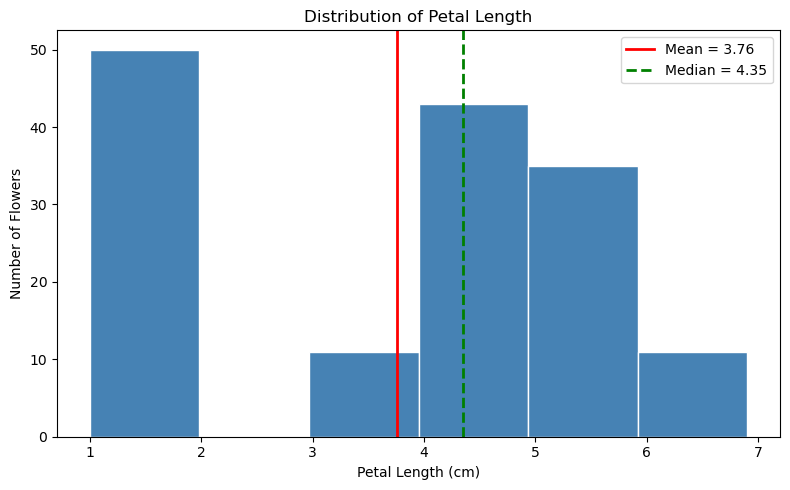

In [10]:
mean_val = df['petal_length'].mean()
median_val = df['petal_length'].median()

plt.figure(figsize=(8, 5))
plt.hist(df['petal_length'], bins=6, color='steelblue', edgecolor='white')

plt.axvline(mean_val, color='red', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linewidth=2, linestyle='--', label=f'Median = {median_val:.2f}')

plt.title('Distribution of Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Number of Flowers')
plt.legend()
plt.tight_layout()
plt.show()

---
## Chart 2 — Boxplot
### Question: How does petal_length compare across species? Any outliers?

**What to explain:**
- The **box** = middle 50% of the data (Q1 to Q3)
- The **line inside the box** = Median
- The **whiskers** = Min and Max (within 1.5 × IQR)
- The **dots outside** = Outliers — unusual values
- Comparing 3 boxes side by side shows you which species is different

C:\Users\ahmed\AppData\Local\Temp\ipykernel_2720\4070045293.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_species, labels=species_list, patch_artist=True,


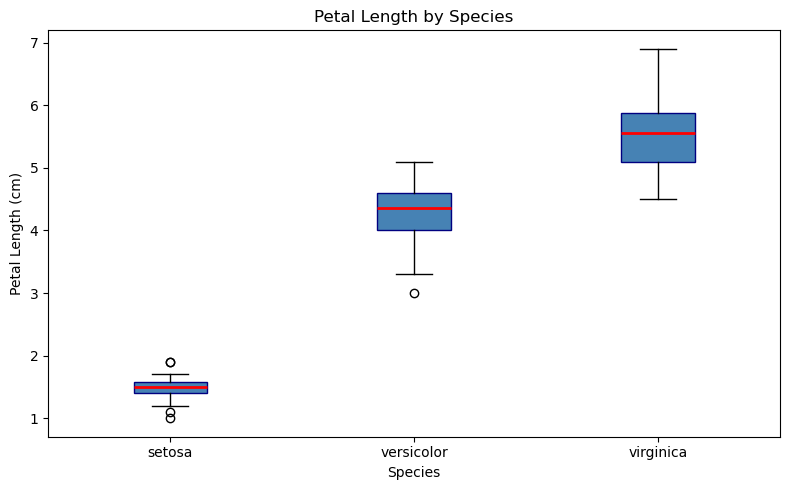

In [11]:
species_list = df['species'].unique()
data_by_species = [df[df['species'] == s]['petal_length'].values for s in species_list]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_species, labels=species_list, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Petal Length by Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.tight_layout()
plt.show()

In [12]:
species_list

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [13]:
len(data_by_species[0])

50

In [14]:
len(data_by_species[0])

50

---
## Chart 3 — Scatter Plot
### Question: Is there a relationship between petal_length and petal_width?

**What to explain:**
- Each dot = one flower
- X-axis = petal_length, Y-axis = petal_width
- If dots form a diagonal line → strong relationship (correlation)
- Color = species → we can see clusters forming naturally
- **Key insight:** Even without a model, the scatter plot separates the 3 species visually!

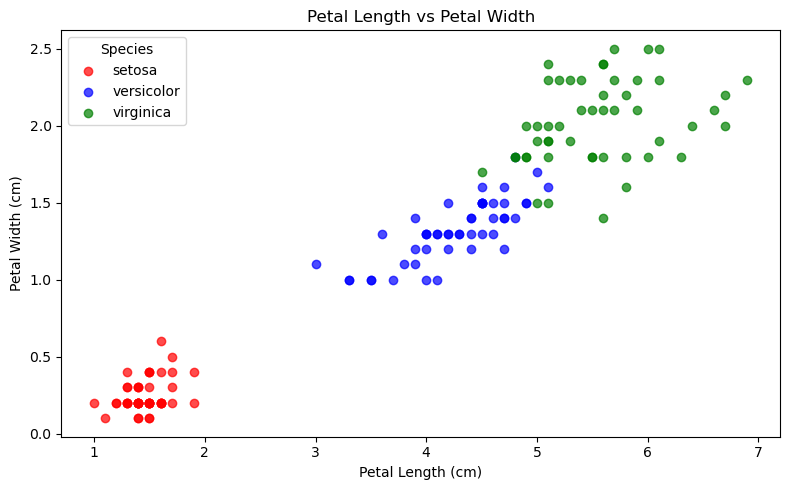

Correlation between petal_length and petal_width: 0.96
→ Close to 1.0 means strong positive relationship


In [15]:
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

plt.figure(figsize=(8, 5))

for species, group in df.groupby('species'):
    plt.scatter(group['petal_length'], group['petal_width'],
                label=species, color=colors[species], alpha=0.7)

plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# Show the correlation number
corr = df['petal_length'].corr(df['petal_width'])
print(f'Correlation between petal_length and petal_width: {corr:.2f}')
print('→ Close to 1.0 means strong positive relationship')